In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon

In [ ]:
df = pd.read_csv('datasheet.csv')
df = df.dropna()
df

,ID,Gender,Age,Country,Instrument(s),Course or Job,MSI,Active Engagement,Singing Ability,Performance Ability,...,Cond2_Expressiveness_Average,Cond2_Enjoyment_Average,ResultsWorthEffort_Count,Exploration_Count,Collab_Count,Immersion_Count,Expressiveness_Count,Enjoyment_Count,Cond1_CSI_Score,Cond2_CSI_Score
0,1.0,Female,20.0,UK,"Drums, Singing",Prefer not to answer,5.20,5.00,5.7,4.0,...,8.5,8.5,4.0,4.0,0.0,1.0,3.0,3.0,78.7,77.7
1,2.0,Male,20.0,UK,Guitar,User Experience Design,4.60,5.00,3.3,6.5,...,4.5,7.5,2.0,5.0,0.0,1.0,4.0,3.0,90.7,62.0
2,3.0,Male,19.0,UK,"Guitar, Keyboard",Graphic Design,5.00,5.00,4.5,6.2,...,6.0,7.0,5.0,3.0,0.0,1.0,3.5,3.0,92.3,66.3
3,4.0,Male,22.0,UK,"Guitar, Drums",Civil Engineer,4.50,4.75,4.5,4.0,...,5.5,5.0,4.0,5.0,0.0,2.0,2.0,2.0,74.0,42.3
4,5.0,Male,25.0,UK,Bass Guitar,Client Liaison,3.61,4.00,4.5,4.5,...,1.0,7.0,5.0,4.0,2.0,1.0,2.0,1.0,41.0,33.7


In [ ]:
wilcoxon(df['Cond1_CSI_Score'], df['Cond2_CSI_Score'])

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.0625))

In [ ]:
wilcoxon(df['Cond1_Expressiveness_Average'], df['Cond2_Expressiveness_Average'])

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.0625))

In [ ]:
wilcoxon(df['Cond1_Enjoyment_Average'], df['Cond2_Enjoyment_Average'])

WilcoxonResult(statistic=np.float64(4.5), pvalue=np.float64(0.5))

In [ ]:
wilcoxon(df['Cond1_ResultsWorthEffortAverage'], df['Cond2_ResultsWorthEffortAverage'])

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.0625))

In [ ]:
wilcoxon(df['Cond1_Exploration_Average'], df['Cond2_Exploration_Average'])

WilcoxonResult(statistic=np.float64(4.5), pvalue=np.float64(0.5))

make confidence interval pictures
put topics in posters

**Reasoning**:
Define the list of column pairs as requested in the instructions.



In [ ]:
column_pairs = [
    ('Cond1_ResultsWorthEffortAverage', 'Cond2_ResultsWorthEffortAverage'),
    ('Cond1_Exploration_Average', 'Cond2_Exploration_Average'),
    ('Cond1_Collab_Average', 'Cond2_Collab_Average'),
    ('Cond1_Immersion_Average', 'Cond2_Immersion_Average'),
    ('Cond1_Expressiveness_Average', 'Cond2_Expressiveness_Average'),
    ('Cond1_Enjoyment_Average', 'Cond2_Enjoyment_Average')
]

In [ ]:
def plot_confidence_intervals(col1_name, col2_name, dataframe):
    """
    Generates side-by-side confidence interval plots with individual participant points
    for two given columns.

    Args:
        col1_name (str): The name of the first column.
        col2_name (str): The name of the second column.
        dataframe (pd.DataFrame): The DataFrame containing the data.
    """
    # Calculate the confidence interval for the first column
    mean_cond1 = dataframe[col1_name].mean()
    std_err_cond1 = dataframe[col1_name].std() / np.sqrt(len(dataframe))
    conf_int_lower_cond1, conf_int_upper_cond1 = mean_cond1 - 1.96 * std_err_cond1, mean_cond1 + 1.96 * std_err_cond1

    # Calculate the confidence interval for the second column
    mean_cond2 = dataframe[col2_name].mean()
    std_err_cond2 = dataframe[col2_name].std() / np.sqrt(len(dataframe))
    conf_int_lower_cond2, conf_int_upper_cond2 = mean_cond2 - 1.96 * std_err_cond2, mean_cond2 + 1.96 * std_err_cond2

    # Define a list of markers and colors to use for each participant
    markers = ['o', 'X', 's', 'P', '*', 'D', '^', 'v', '<', '>'] # Extended example markers
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', '#ee85a2', '#87c38f', '#f4b942'] # Extended example colors

    # Create the subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot for the first column
    axes[0].errorbar(x=[0], y=[mean_cond1], yerr=[[mean_cond1 - conf_int_lower_cond1], [conf_int_upper_cond1 - mean_cond1]], fmt='o', capsize=5, label='95% Confidence Interval')
    # Add individual data points with different markers and colors
    for i, (index, row) in enumerate(dataframe.iterrows()):
        axes[0].scatter(x=[0], y=[row[col1_name]], alpha=0.7, marker=markers[i % len(markers)], color=colors[i % len(colors)], label=f'Participant {int(row["ID"])}')
    axes[0].set_xticks([])
    axes[0].set_ylabel(col1_name)
    axes[0].set_title(f'Confidence Interval for {col1_name}')
    axes[0].grid(axis='y', linestyle='--')
    axes[0].legend()
    y_min1 = np.floor(dataframe[col1_name].min() * 2) / 2.0 - 0.5
    y_max1 = np.ceil(dataframe[col1_name].max() * 2) / 2.0 + 0.5
    axes[0].set_yticks(np.arange(y_min1, y_max1, 0.5))

    # Plot for the second column
    axes[1].errorbar(x=[0], y=[mean_cond2], yerr=[[mean_cond2 - conf_int_lower_cond2], [conf_int_upper_cond2 - mean_cond2]], fmt='o', capsize=5, label='95% Confidence Interval')
    # Add individual data points with different markers and colors
    for i, (index, row) in enumerate(dataframe.iterrows()):
        axes[1].scatter(x=[0], y=[row[col2_name]], alpha=0.7, marker=markers[i % len(markers)], color=colors[i % len(colors)], label=f'Participant {int(row["ID"])}')

    axes[1].set_xticks([])
    axes[1].set_ylabel(col2_name)
    axes[1].set_title(f'Confidence Interval for {col2_name}')
    axes[1].grid(axis='y', linestyle='--')
    axes[1].legend()
    y_min2 = np.floor(dataframe[col2_name].min() * 2) / 2.0 - 0.5
    y_max2 = np.ceil(dataframe[col2_name].max() * 2) / 2.0 + 0.5
    axes[1].set_yticks(np.arange(y_min2, y_max2, 0.5))

    plt.tight_layout()
    plt.show()


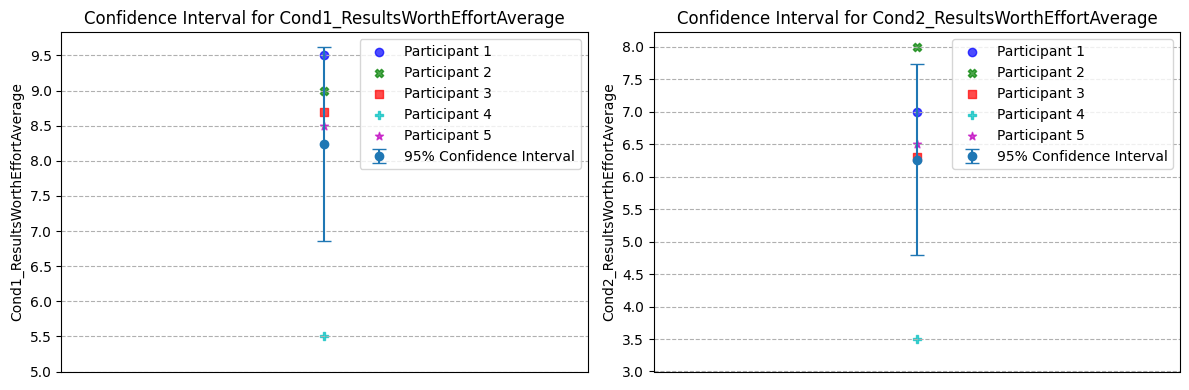

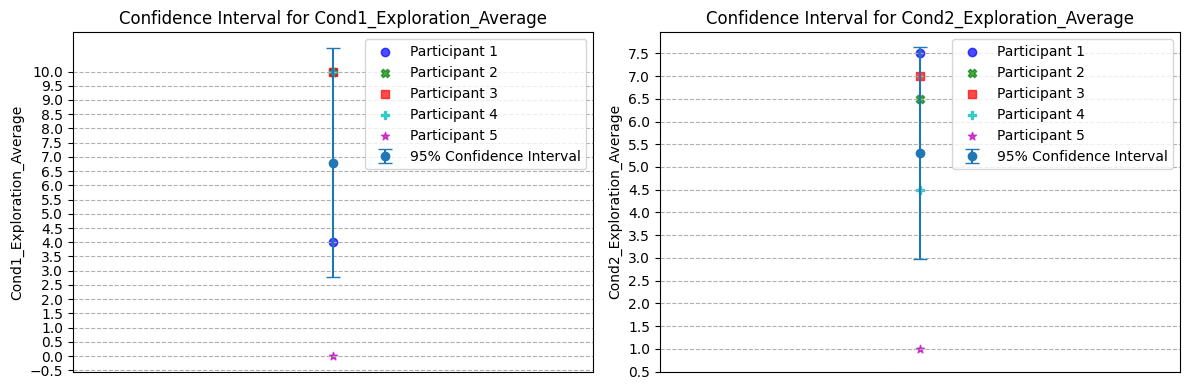

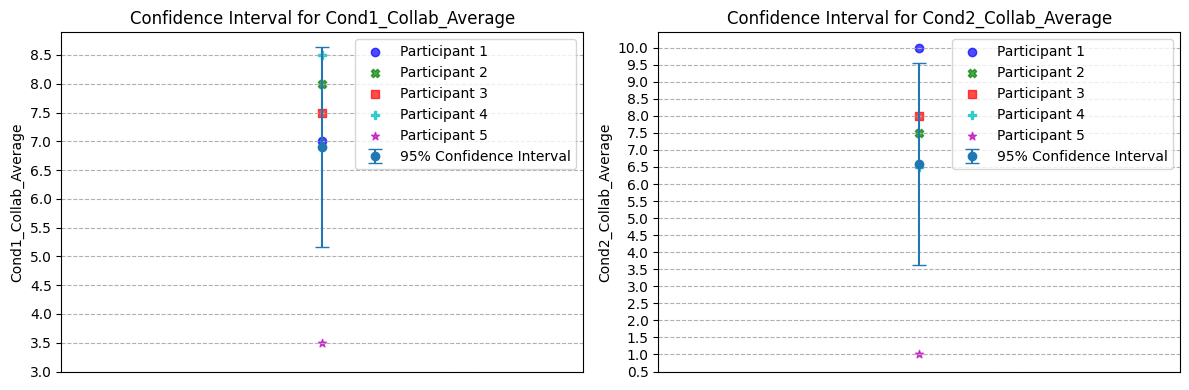

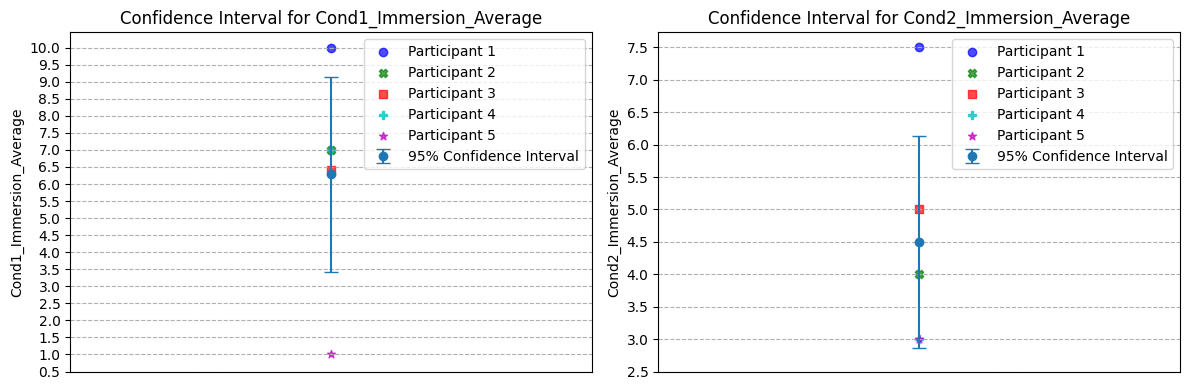

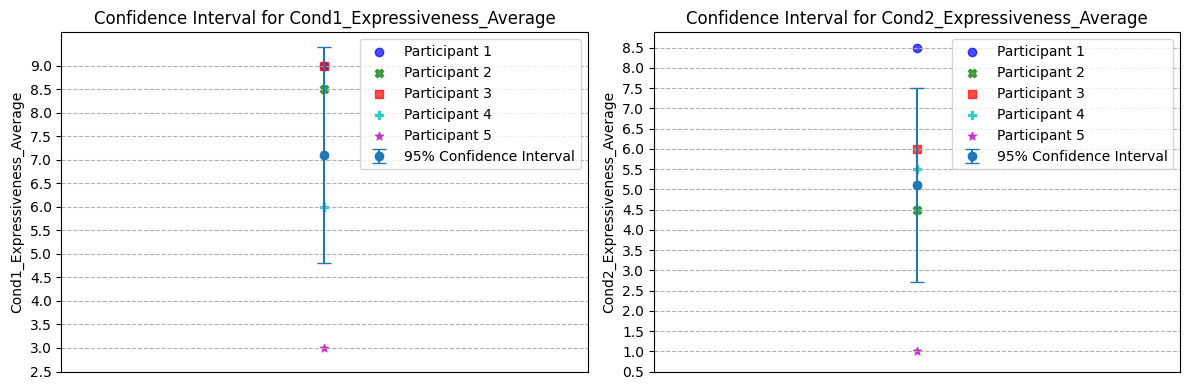

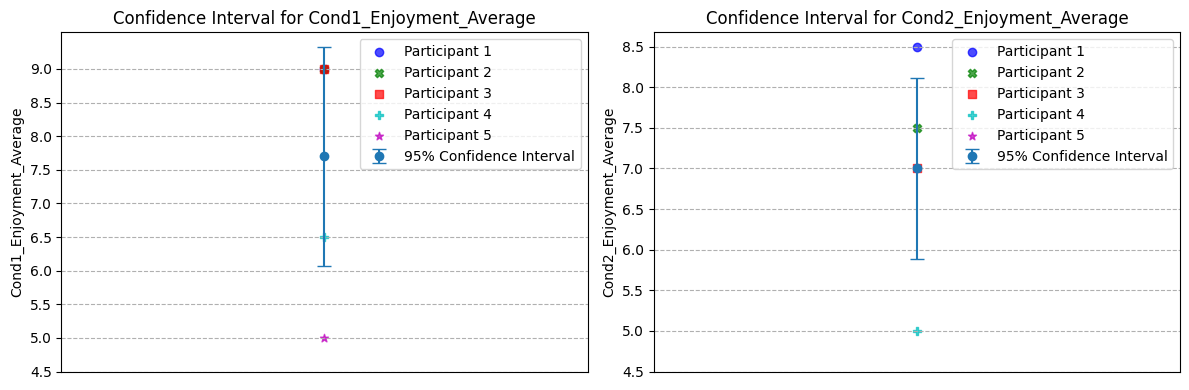

In [ ]:
for col1, col2 in column_pairs:
    plot_confidence_intervals(col1, col2, df)